In [1]:
import numpy as np 
import xarray as xr 
import rioxarray as rxa 
import geopandas as gpd 
import pandas as pd
# import pygeohydro as gh
from pathlib import Path
import os
import sys
from shapely import box

import matplotlib.pyplot as plt
from seaborn import set_theme
set_theme()

project_root = str(Path(os.getcwd()).parent)

if project_root not in sys.path:
    sys.path.append(project_root)

%load_ext autoreload
%autoreload 2
from scripts.layers import assemble_data, assemble_data_largeaoi
from scripts.validation import validate_date_pairs
from scripts.taus import get_taus_spatial, decorrelation_temporal_model

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# WSC poster 

1. For both MCS and a subset of Little cottonwood flights: 
    - Assemble data layers 
    - Fit tau 
    - Find coherence anomalies 
    - Fit a random forest model 
    - Report feature importance 

In [2]:
data_dir = '/bsuhome/julialober/scratch/coherence_data/'
coh_dir = data_dir + 'uavsar_cohs/'
inc_dir = data_dir + 'inc_angle/'
sc_dir = data_dir + 'NSIDC-0768'

summary_file = data_dir + 'campaign_summary_index.parquet'
summary = gpd.read_parquet(summary_file)

### Generate SLC data

In [3]:
SLC_AOI = box(-111.65, 
              40.580, 
              -111.60, 
              40.62) 

In [4]:
slc_summary = summary[summary['flight_path'] == 'stlake']
slc_summary

,flight_path,flight_num,date_pairs,geometry,crs
18,stlake,27129,"[[20200131, 20200213], [20200131, 20200221], [...","POLYGON ((-111.44165 40.51439, -111.44165 40.7...",EPSG:4326


In [5]:
date_pairs = [tuple(p) for p in slc_summary['date_pairs'][18]]
print(date_pairs[:3])
print(len(date_pairs))

[('20200131', '20200213'), ('20200131', '20200221'), ('20200131', '20200312')]
55


In [6]:
slc_summary['flight_num'][18]

'27129'

In [7]:
# ds = gh.nlcd_bygeom(geometry=SLC_AOI, years=['2021'])[0]
# ds

In [8]:
import logging

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s',
    force=True 
)

# data_slc = assemble_data(tile_aoi=SLC_AOI,
#                     date_pairs=date_pairs,
#                     flight_ids=[slc_summary['flight_num'][18]],
#                     fp_coh=coh_dir + 'stlake/',
#                     fp_inc=inc_dir,
#                     fp_snowclimate=sc_dir)
# data_slc

In [9]:
data_slc.to_zarr(data_dir + 'stacks/slc', mode='w', consolidated=True)
# ds_chunked.to_zarr(fp_dest, mode='w', consolidated=True)

NameError: name 'data_slc' is not defined

### Load MCS data

In [3]:
data_file = data_dir + 'stacks/mores_creek2/'
data_mcs = xr.open_zarr(data_file)

In [4]:
mcs_outline = data_dir + '/mores_creek_site/dem/SNEX20_QSI_DEM_0.5M_USIDMC_20210917_20210917.tif'
outline = rxa.open_rasterio(mcs_outline)

In [5]:
# outline = outline.rio.reproject_match(data_mcs)
from rasterio.enums import Resampling
outline = outline.rio.reproject(outline.rio.crs, resampling=Resampling.average, resolution=(5, 5))
outline = outline.rio.reproject('EPSG:4326')
outline = outline.squeeze()
outline = outline.where(outline != outline.rio.nodata)

In [6]:
outline = outline.squeeze()
outline = outline.rio.reproject_match(data_mcs)
nan_mask = outline.where(outline != outline.rio.nodata).isnull()

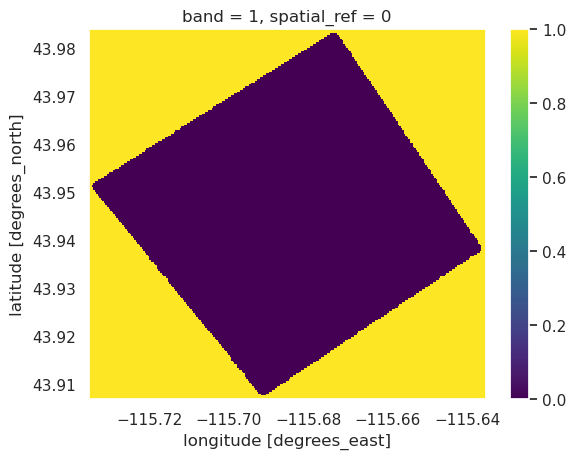

In [7]:
nan_mask.plot()

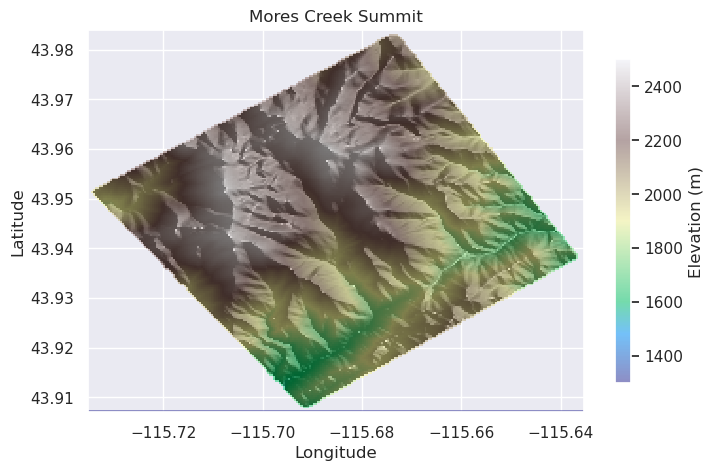

Elevation change: 3.4028234663852886e+38


In [8]:
from matplotlib.colors import LightSource

# create hillshade from DEM
ls = LightSource(azdeg=60, altdeg=60)
hillshade = ls.hillshade(outline.values, vert_exag=1)

# print(hillshade.shape)
dem_shade = outline.copy(data = hillshade)

# plot DEM with hillshading
# plt.style.use('light_background')
fig, ax = plt.subplots(figsize=(8, 6))
# ax = plt.gca() # Get current axes

# fig.set_facecolor('#e1ebe9')

# Plot hillshade as the base layer
hs = dem_shade.plot(ax=ax, cmap='gray', add_colorbar=False)
elev = outline.plot(ax=ax, cmap='terrain', vmin=1300, vmax=2500, add_colorbar=False, alpha=0.5) 
# add points of interest
# ax.plot(mcs_snotel[1], mcs_snotel[0], marker=mcs_snotel_marker, color=mcs_snotel_color, linestyle='None', markersize=10, label='Snotel Site')
# ax.plot(pilot_n[1], pilot_n[0], marker=pilot_n_marker, color=pilot_n_color, linestyle='None', markersize=7, label='High Tau')
# ax.plot(pilot_s[1], pilot_s[0], marker=pilot_s_marker, color=pilot_s_color, linestyle='None', markersize=7, label='Low Tau')
# ax.legend(frameon=False, loc='upper right')
ax.set_aspect('equal')
ax.grid(True)
ax.set_axisbelow(True)
# ax.set_facecolor('darkgray')

plt.title("Mores Creek Summit")
plt.colorbar(elev, alpha = 1, label="Elevation (m)", shrink=0.7)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

print(f'Elevation change: {np.nanmax(outline) - np.nanmin(outline)}')

In [9]:
# for var in data_mcs.data_vars:
#     if 'x' in data_mcs[var].dims and 'y' in data_mcs[var].dims:
#         data_mcs[var] = data_mcs[var].where(~nan_mask.astype(bool), drop=False)
data_mcs = data_mcs.where(nan_mask == 0)
data_mcs

<xarray.Dataset> Size: 680MB
Dimensions:             (pair: 78, y: 202, x: 262, flight_id: 2)
Coordinates:
  * pair                (pair) <U13 4kB '200131_200213' ... '210316_210322'
  * y                   (y) float64 2kB 43.98 43.98 43.98 ... 43.91 43.91 43.91
  * x                   (x) float64 2kB -115.7 -115.7 -115.7 ... -115.6 -115.6
  * flight_id           (flight_id) <U5 40B '05208' '23205'
    band                int64 8B 1
    crs                 int64 8B ...
    spatial_ref         int64 8B 0
Data variables: (12/30)
    acq_day_precip      (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    aspect              (y, x) float32 212kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    avg_precip          (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    avg_rain            (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    avg_snow            (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    big_accum           (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    ...                  ...
    temp_diff           (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    temp_diff_acq       (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    total_posdeg        (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    total_precip        (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    total_rain          (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    total_snow          (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>

In [10]:
dates = data_mcs['coherence'].coords['pair'].values
dates

array(['200131_200213', '200131_200221', '200131_200311', '200131_210115',
       '200131_210120', '200131_210127', '200131_210203', '200131_210210',
       '200131_210303', '200131_210310', '200131_210316', '200131_210322',
       '200213_200221', '200213_200311', '200213_210115', '200213_210120',
       '200213_210127', '200213_210203', '200213_210210', '200213_210303',
       '200213_210310', '200213_210316', '200213_210322', '200221_200311',
       '200221_210115', '200221_210120', '200221_210127', '200221_210203',
       '200221_210210', '200221_210303', '200221_210310', '200221_210316',
       '200221_210322', '200311_210115', '200311_210120', '200311_210127',
       '200311_210203', '200311_210210', '200311_210303', '200311_210310',
       '200311_210316', '200311_210322', '210115_210120', '210115_210127',
       '210115_210203', '210115_210210', '210115_210303', '210115_210310',
       '210115_210316', '210115_210322', '210120_210127', '210120_210203',
       '210120_210210', '

In [11]:
time_dif = []
# counter = 0
# for i in range(len(dates)) : 
#     for j in range(i, len(dates)) : 
#         if (i == j) : 
#             # time_dif[i, j] = np.nan
#             continue
#         timedelt = pd.to_datetime(dates[j]) - pd.to_datetime(dates[i])
#         time_dif.append(timedelt.total_seconds() / (24 * 60 * 60))

for d in dates: 
    d1, d2 = d.split('_')
    
    timedelt = pd.to_datetime('20' + d2) - pd.to_datetime('20' + d1)
    time_dif.append(timedelt.total_seconds() / (24 * 60 * 60))
        # counter += 1
print(time_dif)
print(len(time_dif))

[13.0, 21.0, 40.0, 350.0, 355.0, 362.0, 369.0, 376.0, 397.0, 404.0, 410.0, 416.0, 8.0, 27.0, 337.0, 342.0, 349.0, 356.0, 363.0, 384.0, 391.0, 397.0, 403.0, 19.0, 329.0, 334.0, 341.0, 348.0, 355.0, 376.0, 383.0, 389.0, 395.0, 310.0, 315.0, 322.0, 329.0, 336.0, 357.0, 364.0, 370.0, 376.0, 5.0, 12.0, 19.0, 26.0, 47.0, 54.0, 60.0, 66.0, 7.0, 14.0, 21.0, 42.0, 49.0, 55.0, 61.0, 7.0, 14.0, 35.0, 42.0, 48.0, 54.0, 7.0, 28.0, 35.0, 41.0, 47.0, 21.0, 28.0, 34.0, 40.0, 7.0, 13.0, 19.0, 6.0, 12.0, 6.0]
78


In [12]:
data_mcs['coherence'].sel(flight_id='05208').values 

array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       ...,

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan

In [13]:
# taus = get_taus_spatial(data_mcs['coherence'].sel(flight_id='05208'),
#                         time_dif)

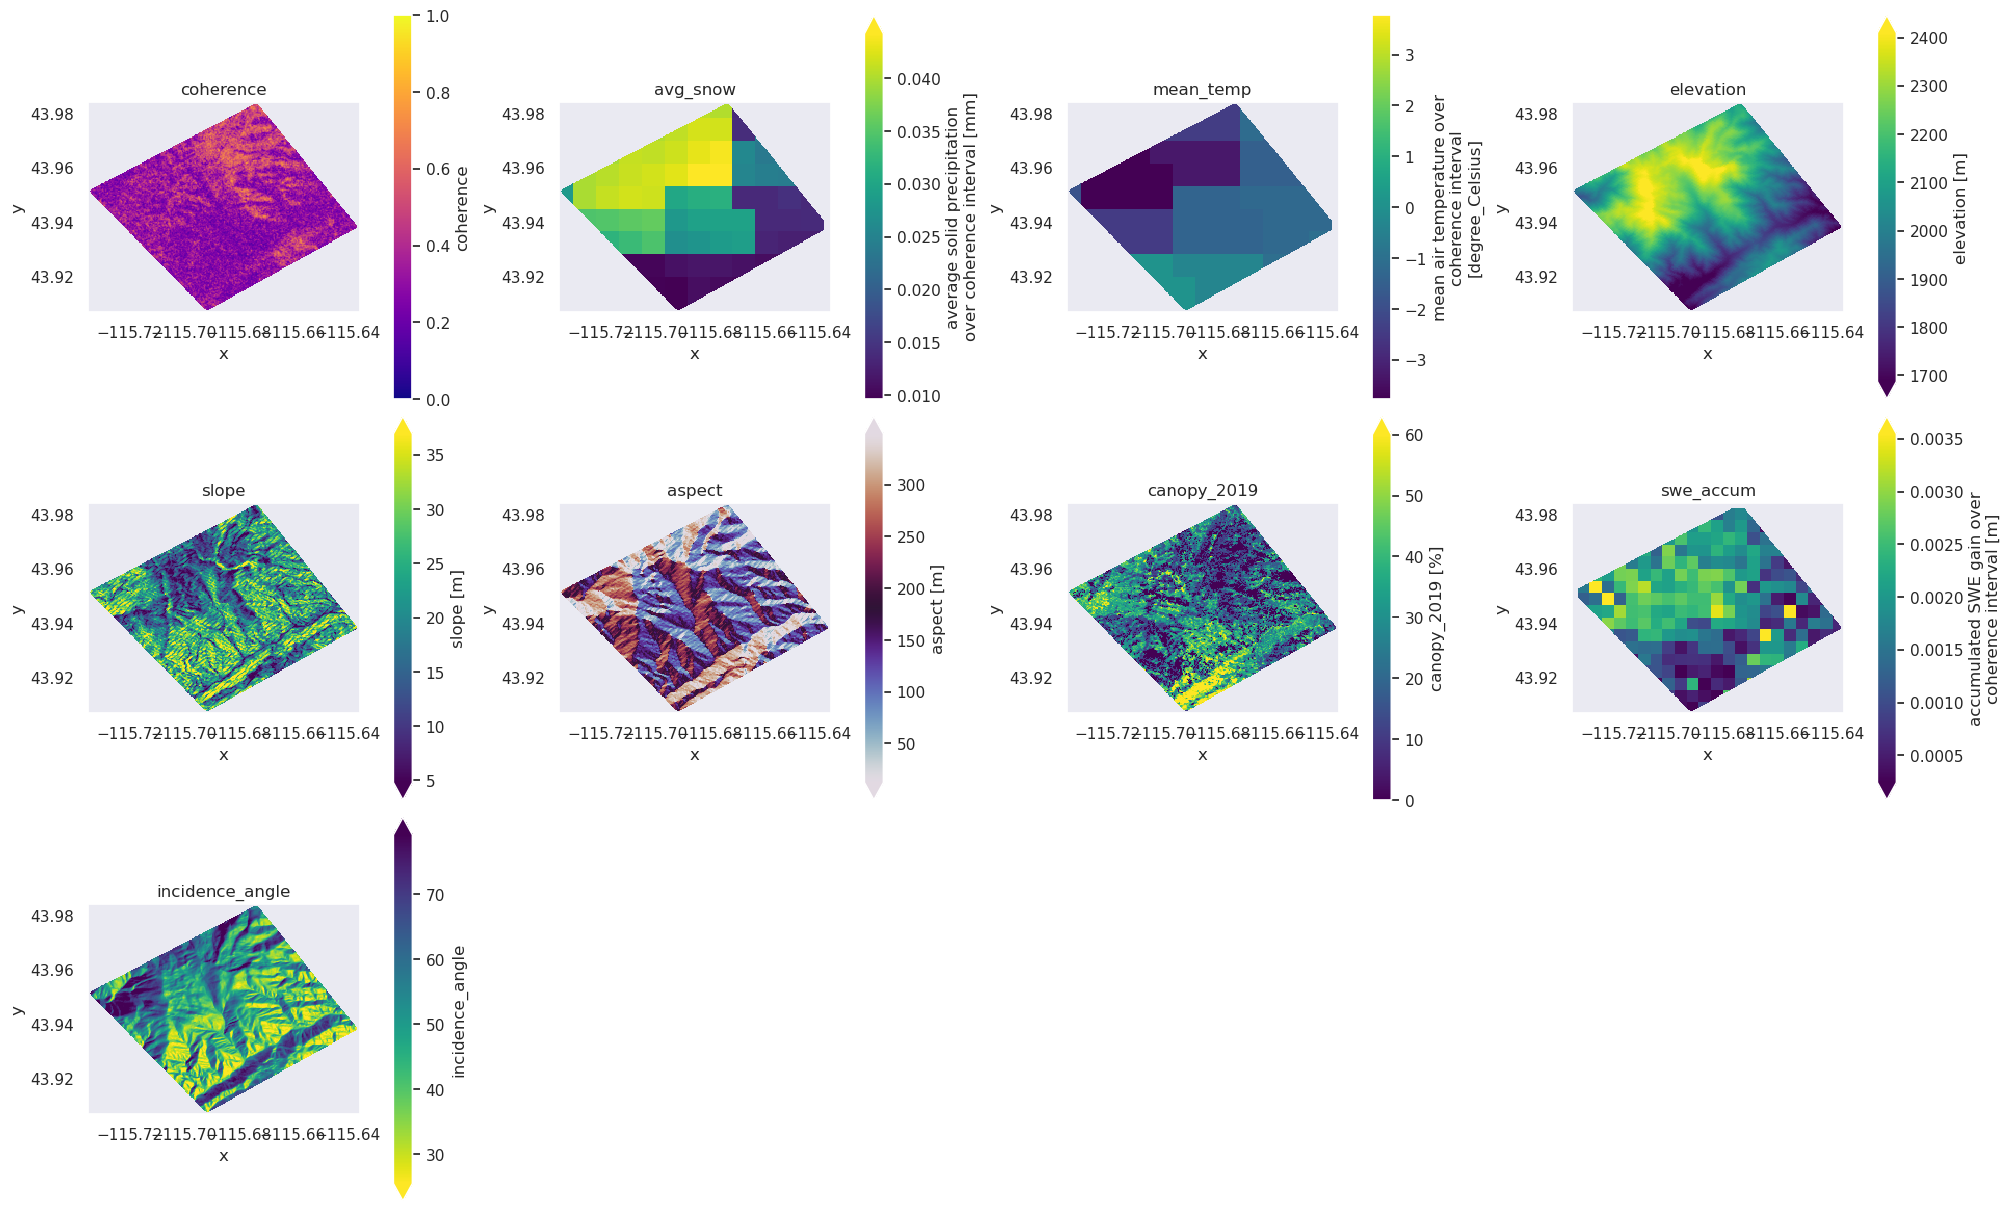

In [14]:
# fg = data[var].sel(pair=dates).plot(
#         col='pair',
#         col_wrap=5,  # 5 plots per row looks nice for 45 pairs
#         figsize=(15, 3 * int(np.ceil(len(dates) / 5))),
#         robust=True,
#         cmap=cmap
#     )
vars_to_plot = [
    'coherence', 'avg_snow', 'mean_temp', 'elevation', 
    'slope', 'aspect', 'canopy_2019', 'swe_accum', 'incidence_angle'
]

# 2. Setup the grid (5 columns as requested)
ncols = 4
nrows = int(np.ceil(len(vars_to_plot) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(20, 4 * nrows), constrained_layout=True)
axes = axes.flatten() # Flatten to loop easily

# 3. Selection criteria
f_id = '05208'
p_id = '200221_200311'

for i, var in enumerate(vars_to_plot):
    ax = axes[i]

    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in 'coherence': cmap = 'plasma'
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    elif var in 'incidence_angle': cmap = 'viridis_r'
    else : cmap = 'viridis'  # standard colormap for other variables
    
    # Get the specific DataArray
    da = data_mcs[var]
    
    # Dynamically select dimensions if they exist in this variable
    selector = {}
    if 'flight_id' in da.dims:
        selector['flight_id'] = f_id
    if 'pair' in da.dims:
        selector['pair'] = p_id
    
    # Apply selection and plot
    data_slice = da.sel(**selector)
    if var in 'coherence': 
        data_slice.plot(ax=ax, x='x', y='y', robust=True, add_colorbar=True, cmap=cmap, vmin=0, vmax=1)
    else: 
        data_slice.plot(ax=ax, x='x', y='y', robust=True, add_colorbar=True, cmap=cmap)
    
    ax.set_title(f"{var}")
    ax.set_aspect('equal')
    # ax.set_axis_off() # Optional: cleans up the plot if lat/lon labels overlap

# 4. Remove empty subplots if the grid isn't full
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.show()

In [15]:
data_mcs.data_vars

Data variables:
    acq_day_precip      (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    aspect              (y, x) float32 212kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    avg_precip          (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    avg_rain            (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    avg_snow            (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    big_accum           (pair, y, x) float64 33MB dask.array<chunksize=(20, 51, 131), meta=np.ndarray>
    canopy_2019         (y, x) float32 212kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    coherence           (flight_id, pair, y, x) float32 33MB dask.array<chunksize=(1, 20, 101, 131), meta=np.ndarray>
    cover_2019          (y, x) float64 423kB dask.array<chunksize=(202, 262), meta=np.ndarray>
    curve               (y, x) float32 212kB dask.array<chunksize=

In [16]:
from scipy import stats

def cohen_d(x, y):
    nx, ny = len(x), len(y)
    var_x, var_y = np.var(x, ddof=1), np.var(y, ddof=1)
    pooled_sd = np.sqrt(((nx - 1) * var_x + (ny - 1) * var_y) / (nx + ny - 2))
    return (np.mean(y) - np.mean(x)) / pooled_sd


# 1. Selection criteria
f_id = '05208'
pair_A = '210310_210316'
pair_B = '210316_210322'

results = []

for var in data_mcs.data_vars:
    da = data_mcs[var]
    
    # Selection logic for both dates
    selector_A = {k: v for k, v in {'flight_id': f_id, 'pair': pair_A}.items() if k in da.dims}
    selector_B = {k: v for k, v in {'flight_id': f_id, 'pair': pair_B}.items() if k in da.dims}
    
    data_A = da.sel(**selector_A).values.flatten()
    data_B = da.sel(**selector_B).values.flatten()
    
    # Remove NaNs (important: must remove at same indices for paired tests)
    mask = ~np.isnan(data_A) & ~np.isnan(data_B)
    clean_A = data_A[mask]
    clean_B = data_B[mask]
    d_val = cohen_d(clean_A, clean_B)
    # print(f"{var} Cohen's d: {d_val:.2f}")
    
    if len(clean_A) > 30: # Ensure enough samples for validity
        # Wilcoxon is more robust for environmental data which is often non-normal
        stat, p_val = stats.wilcoxon(clean_A, clean_B)
        
        results.append({
            'Variable': var,
            'Mean_A': np.mean(clean_A),
            'Mean_B': np.mean(clean_B),
            'Diff': np.mean(clean_B) - np.mean(clean_A),
            'p-value': p_val,
            'Significant': p_val < 0.05,
            'Cohen\'s d:': d_val
        })

# 3. View as a clean table
stats_df = pd.DataFrame(results)
stats_df

/tmp/ipykernel_254409/1271537175.py:7: RuntimeWarning: invalid value encountered in scalar divide
  return (np.mean(y) - np.mean(x)) / pooled_sd
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


,Variable,Mean_A,Mean_B,Diff,p-value,Significant,Cohen's d:
0,acq_day_precip,0.000000,0.000000,0.000000,NaN,False,NaN
1,aspect,175.743759,175.743759,0.000000,NaN,False,0.000000
2,avg_precip,0.000000,0.119380,0.119380,0.0,True,16.464565
3,avg_rain,0.000000,0.059969,0.059969,0.0,True,3.608729
4,avg_snow,0.000000,0.059411,0.059411,0.0,True,2.633653
5,big_accum,0.000000,0.000000,0.000000,NaN,False,NaN
6,canopy_2019,23.557180,23.557180,0.000000,NaN,False,0.000000
7,coherence,0.475605,0.322845,-0.152760,0.0,True,-1.554593
8,cover_2019,52.680749,52.680749,0.000000,NaN,False,0.000000
9,curve,0.009237,0.009237,0.000000,NaN,False,0.000000


/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/scipy/stats/_wilcoxon.py:181: RuntimeWarning: invalid value encountered in scalar divide
  z = (r_plus - mn) / se


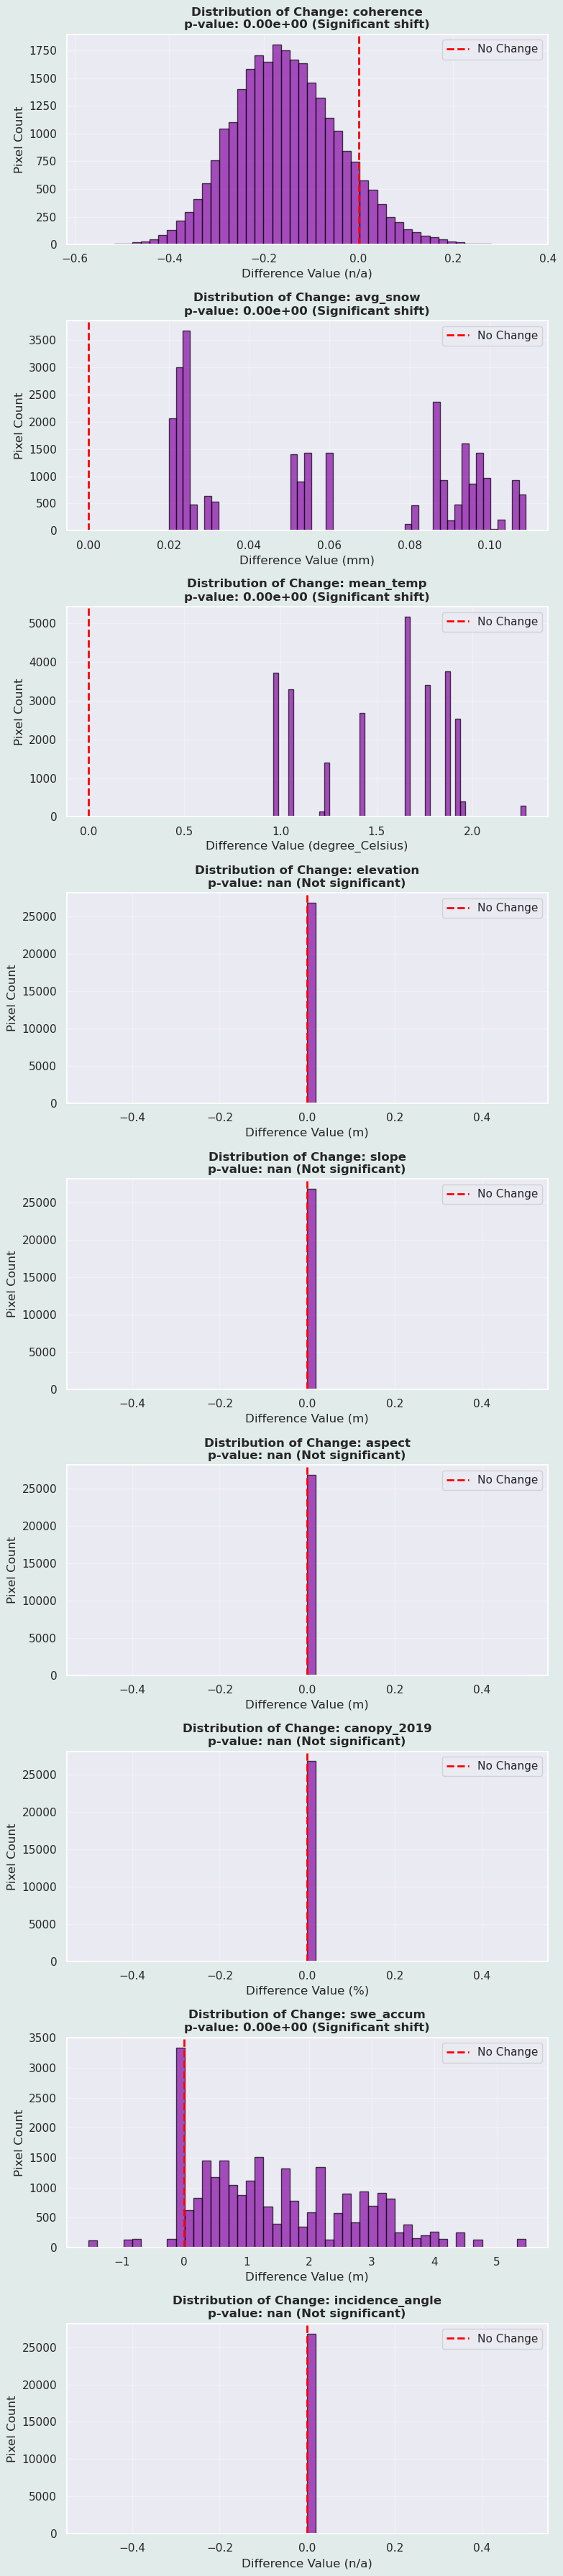

In [17]:
# 1. Setup the figure
fig, axes = plt.subplots(len(vars_to_plot), 1, figsize=(8, 4 * len(vars_to_plot)))
fig.set_facecolor('#e1ebe9')

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    # Get DataArrays for both pairs
    da = data_mcs[var]
    sel_A = {k: v for k, v in {'flight_id': f_id, 'pair': pair_A}.items() if k in da.dims}
    sel_B = {k: v for k, v in {'flight_id': f_id, 'pair': pair_B}.items() if k in da.dims}
    
    data_A = da.sel(**sel_A).values.flatten()
    data_B = da.sel(**sel_B).values.flatten()
    
    # Handle SWE conversion
    if var == 'swe_accum':
        data_A *= 1000
        data_B *= 1000
        
    # Mask NaNs and calculate per-pixel difference
    mask = ~np.isnan(data_A) & ~np.isnan(data_B)
    diff = data_B[mask] - data_A[mask]
    
    # 2. Plot Histogram of Differences
    ax.hist(diff, bins=50, color='#8708a6', alpha=0.7, edgecolor='black')
    
    # Add a red dashed line at 0 (the 'null hypothesis' line)
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='No Change')
    
    # 3. Perform Wilcoxon Signed-Rank test
    stat, p_val = stats.wilcoxon(data_A[mask], data_B[mask])
    
    # 4. Formatting
    title_suffix = f"(Significant shift)" if p_val < 0.05 else "(Not significant)"
    ax.set_title(f"Distribution of Change: {var}\np-value: {p_val:.2e} {title_suffix}", 
                 fontsize=12, fontweight='bold')
    ax.set_xlabel(f"Difference Value ({da.attrs.get('units', 'n/a')})")
    ax.set_ylabel("Pixel Count")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

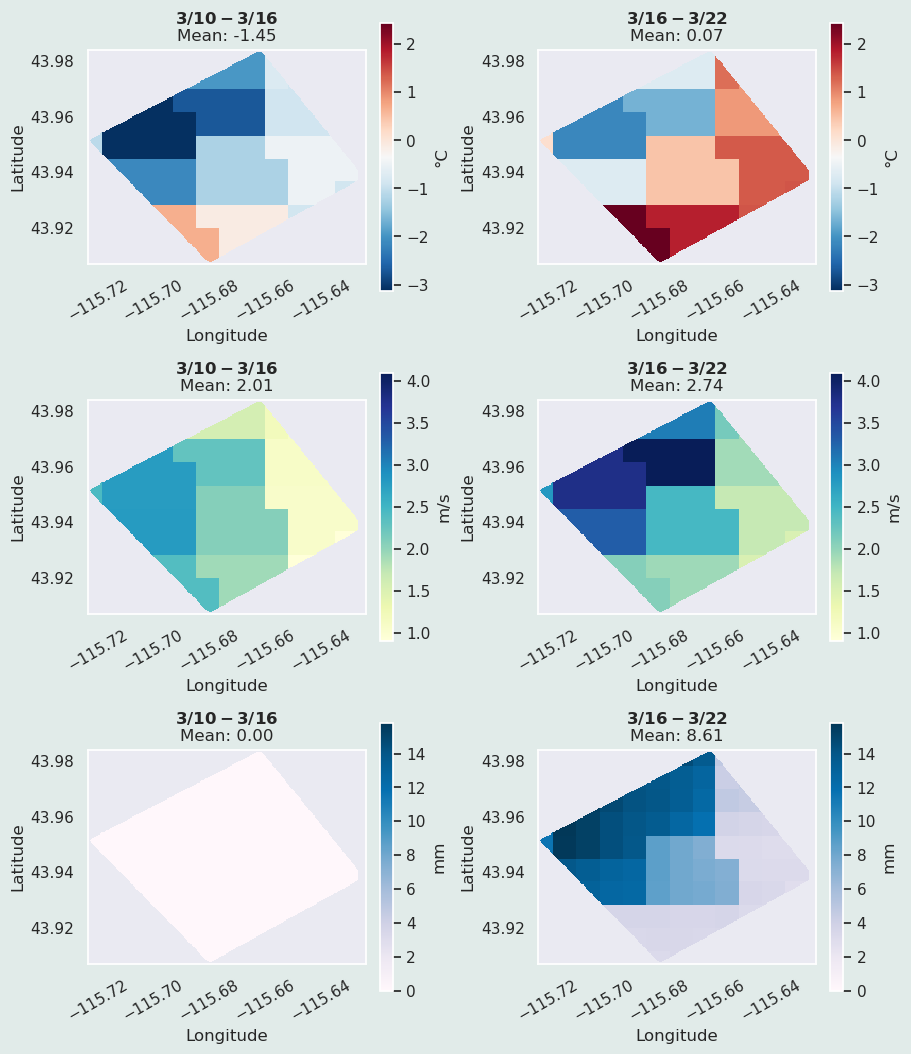

In [44]:
# 1. Define your parameters
vars_to_plot = data_mcs.data_vars
vars_to_plot = [
    'coherence', 'mean_temp', 'mean_wind', 'total_snow', #'density_change', 'swe_accum', 'mean_wind', 'swe_ablate', 'total_snow'
]
vars_to_plot = [
     'mean_temp', 'mean_wind', 'total_snow', 
]
var_labels = {
    'coherence': '', 
    'mean_temp': '°C', 
    'mean_wind': 'm/s', 
    'total_snow': 'mm'
}
pairs_to_compare = ['210310_210316', '210316_210322']
pair_names = ['3/10-3/16', '3/16-3/22']
f_id = '05208'

nrows = len(vars_to_plot)
ncols = 2

# 2. Create the figure
fig, axes = plt.subplots(nrows, ncols, figsize=(9, 3.5 * nrows), constrained_layout=True)

fig.set_facecolor('#e1ebe9')

# 3. Nested loop: Variables (Rows) x Pairs (Columns)
for row_idx, var in enumerate(vars_to_plot):
    
    # --- SYNCHRONIZE COLOR SCALE ---
    # Select the data for ALL pairs in this row to find global min/max
    da = data_mcs[var]
    row_selector = {'flight_id': f_id, 'pair': pairs_to_compare}
    # Subset to just the pairs we are plotting to find the shared range
    row_data = da.sel(**{k: v for k, v in row_selector.items() if k in da.dims})
    
    v_min = float(row_data.min())
    v_max = float(row_data.max())

    if var == 'coherence': v_min, v_max = (0, 1)
    
    # Optional: use robust percentiles if you have outliers
    # v_min, v_max = np.percentile(row_data.values.flatten(), [2, 98])

    for col_idx, p_id in enumerate(pairs_to_compare):
        ax = axes[row_idx, col_idx]

        # Colormap Logic
        if var == 'aspect': cmap = 'twilight'
        elif var == 'coherence': cmap = 'plasma'
        elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'
        elif var == 'mean_temp': cmap = 'RdBu_r' 
        elif var == 'mean_wind': cmap = 'YlGnBu'
        elif var == 'total_snow': cmap = 'PuBu'
        else: cmap = 'viridis'
        
        # Apply specific selection
        selector = {k: v for k, v in {'flight_id': f_id, 'pair': p_id}.items() if k in da.dims}
        data_slice = da.sel(**selector)
        
        # Plotting with shared vmin/vmax
        # We set add_colorbar=True but we will catch the object to edit it
        im = data_slice.plot(
            ax=ax, x='x', y='y', 
            cmap=cmap, 
            vmin=v_min, vmax=v_max, 
            add_colorbar=True,
            cbar_kwargs={'label': f'{var_labels[var]}'} #({da.attrs.get("units", "n/a")})'} 
        )
        
        ax.set_aspect('equal')
        ax.tick_params(axis='x', rotation=30)
        plt.setp(ax.get_xticklabels(), ha='right')
        
        # --- BOLD FIRST LINE IN TITLE ---
        # Using Matplotlib's mathtext for bolding specific lines
        ax.set_title(r"$\bf{" + pair_names[col_idx] + "}$" + f'\nMean: {data_slice.mean().values:.2f}')
            
        # Axis Labels
        ax.set_ylabel("Latitude")
        ax.set_xlabel("Longitude")

plt.show()

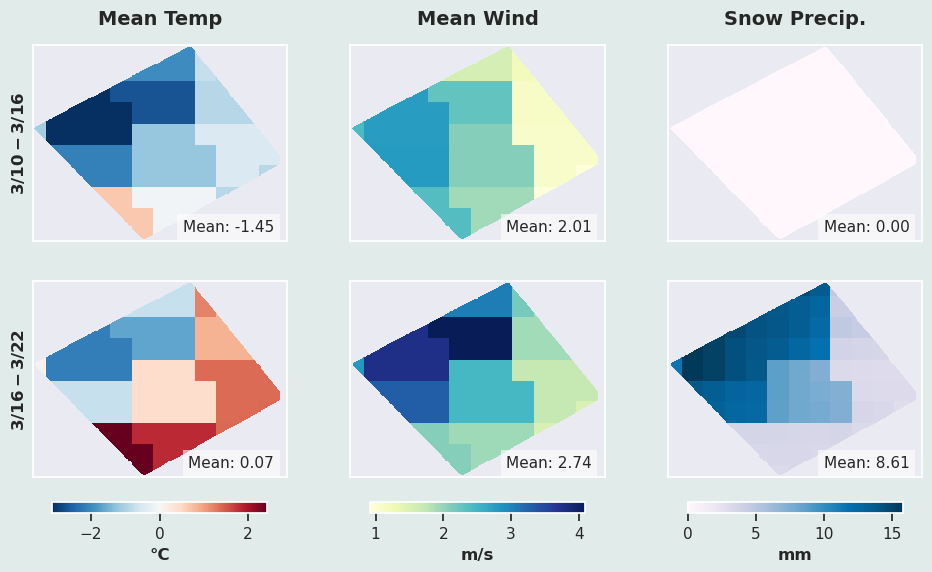

In [88]:
from matplotlib.colors import TwoSlopeNorm

# 1. Define your parameters
vars_to_plot = ['mean_temp', 'mean_wind', 'total_snow']
var_titles = {'mean_temp': 'Mean Temp', 'mean_wind': 'Mean Wind', 'max_wind': 'Max Wind', 'total_snow': 'Snow Precip.'} 
var_labels = {'mean_temp': '°C', 'mean_wind': 'm/s', 'max_wind': 'm/s', 'total_snow': 'mm'}
pairs_to_compare = ['210310_210316', '210316_210322']
pair_names = ['3/10-3/16', '3/16-3/22']
f_id = '05208'

# Flipped grid dimensions
nrows = len(pairs_to_compare)
ncols = len(vars_to_plot)

# 2. Create the figure
# Using a larger width since variables are now columns
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.95 * nrows), constrained_layout={'h_pad': 0.2, 'w_pad': 0.05})
fig.set_facecolor('#e1ebe9')

# 3. Nested loop: Pairs (Rows) x Variables (Columns)
for col_idx, var in enumerate(vars_to_plot):
    
    # --- SYNCHRONIZE COLOR SCALE PER COLUMN ---
    da = data_mcs[var]
    row_selector = {'flight_id': f_id, 'pair': pairs_to_compare}
    row_data = da.sel(**{k: v for k, v in row_selector.items() if k in da.dims})
    
    v_min, v_max = float(row_data.min()), float(row_data.max())
    if var == 'coherence': v_min, v_max = (0, 1)

    # Choose colormap
    if var == 'mean_temp': cmap = 'RdBu_r' 
    elif var == 'mean_wind': cmap = 'YlGnBu'
    elif var == 'max_wind': cmap = 'YlGnBu'
    elif var == 'total_snow': cmap = 'PuBu'
    else: cmap = 'viridis'

    # make 0 white for mean_temp
    if var == 'mean_temp':
        cmap = 'RdBu_r'
        if v_min < 0 < v_max:
            norm = TwoSlopeNorm(vmin=v_min, vcenter=0, vmax=v_max)
        else:
            norm = None # Fall back to standard scaling if 0 isn't in range
    else:
        norm = None # Standard linear scaling for other variables

    for row_idx, p_id in enumerate(pairs_to_compare):
        ax = axes[row_idx, col_idx]
        
        selector = {k: v for k, v in {'flight_id': f_id, 'pair': p_id}.items() if k in da.dims}
        data_slice = da.sel(**selector)
        
        # Plotting - Turn off individual colorbars
        im = data_slice.plot(
            ax=ax, x='x', y='y', 
            cmap=cmap, 
            norm=norm,
            vmin=v_min, 
            vmax=v_max, 
            add_colorbar=False,
        )
        
        ax.set_aspect('equal')
        
        # --- BOLD COLUMN LABELS (Top Row Only) ---
        if row_idx == 0:
            ax.set_title(var_titles[var], fontweight='bold', fontsize=14, pad=15)
        else:
            ax.set_title("") # Clear titles for other rows

        # --- BOLD ROW LABELS (Left Column Only) ---
        if col_idx == 0:
            ax.set_ylabel(r"$\bf{" + pair_names[row_idx] + "}$" + "", fontsize=12)
        else:
            ax.set_ylabel("")
        
        if row_idx == 1:
            ax.set_xlabel("", fontsize=12)
        else:
            ax.set_xlabel("")
        
        # Inside your loop:
        if row_idx < nrows - 1:
            ax.set_xticks([])
            ax.set_xlabel("") # Remove 'Longitude' from middle plots
            
        if col_idx > 0:
            ax.set_yticks([])
            ax.set_ylabel("") # Remove 'Latitude' from middle plots

        ax.set_xticks([])
        ax.set_yticks([])

        # Mean stat annotation
        ax.text(0.95, 0.05, f'Mean: {data_slice.mean().values:.2f}', 
                transform=ax.transAxes, ha='right', fontsize=11, 
                bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

        # --- ADD SHARED COLORBAR (Bottom Row Only) ---
        if row_idx == nrows - 1:
            cbar = fig.colorbar(im, ax=axes[:, col_idx], shrink=0.7, orientation='horizontal', pad=0.05)
            cbar.set_label(f'{var_labels[var]}', fontweight='bold')

        # Tick cleanup
        ax.tick_params(axis='x', rotation=30)
        plt.setp(ax.get_xticklabels(), ha='right')

# plt.subplots_adjust(hspace=0.4)
plt.show()

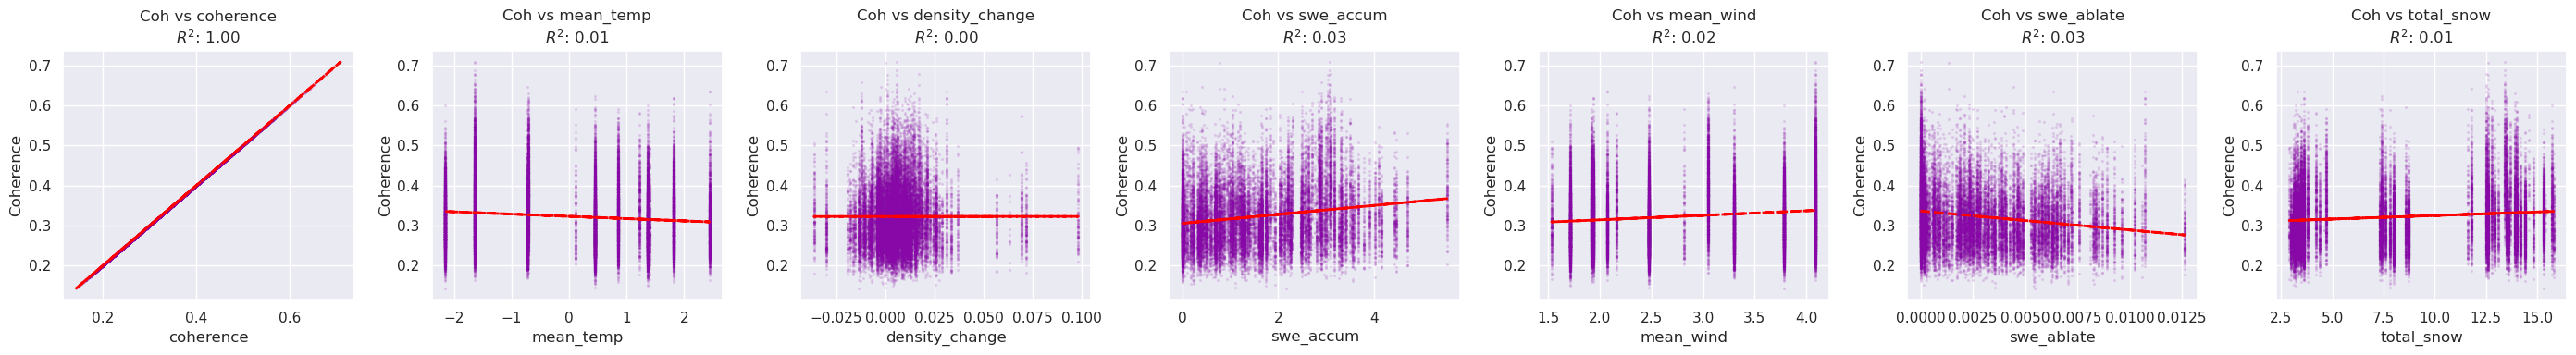

In [19]:
# 2. Setup the grid
fig, axes = plt.subplots(1, len(vars_to_plot), figsize=(4 * len(vars_to_plot), 4))

# Get coherence once as the X-axis reference
coh_da = data_mcs['coherence'].sel(flight_id=f_id, pair=p_id)

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    
    # Get Y-axis variable
    da = data_mcs[var]
    selector = {k: v for k, v in {'flight_id': f_id, 'pair': p_id}.items() if k in da.dims}
    y_data = da.sel(**selector)
    
    # Conversion for SWE if needed
    if var == 'swe_accum':
        y_data = y_data * 1000

    # Align data (flatten into 1D arrays and drop NaNs)
    # We use .values.flatten() to treat every pixel as a point
    y_vals = coh_da.values.flatten()
    x_vals = y_data.values.flatten()
    
    # Filter out NaNs so the trendline/hexbin doesn't break
    mask = ~np.isnan(x_vals) & ~np.isnan(y_vals)
    x_clean = x_vals[mask]
    y_clean = y_vals[mask]

    # Plot Density (Hexbin)
    # hb = ax.hexbin(x_clean, y_clean, gridsize=30, cmap='YlGnBu', mincnt=1)

    # Standard scatter with transparency
    ax.scatter(x_clean, y_clean, s=2, alpha=0.1, color='#8708a6')

    
    # Add a simple linear trendline
    if len(x_clean) > 0:
        m, b = np.polyfit(x_clean, y_clean, 1)
        ax.plot(x_clean, m*x_clean + b, color='red', lw=2, linestyle='--')

    # Formatting
    ax.set_xlabel(var)
    ax.set_ylabel('Coherence')
    ax.set_title(f'Coh vs {var}\n$R^2$: {np.corrcoef(x_clean, y_clean)[0,1]**2:.2f}')
    # plt.colorbar(hb, ax=ax, label='Point Density')

plt.tight_layout()
plt.show()

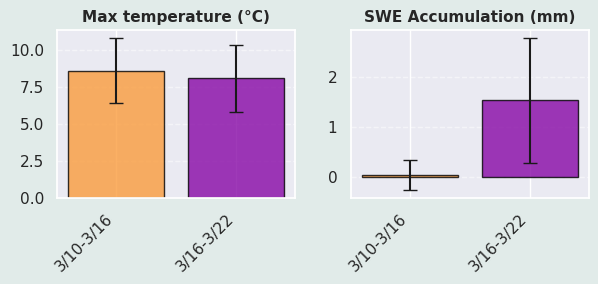

In [20]:
# 1. Variables and Title selection
vars_to_plot = [
    'max_temp', 'swe_accum', #'mean_temp', 'mean_wind', 'swe_accum', 'density_change'
]
vars_titles = [
    'Max temperature (°C)', 'SWE Accumulation (mm)', #'Mean Temperature (°C)', 'Mean wind (m/s)', 
    #'Density change'
]

# 2. Setup the figure: Horizontal layout (1 row, N columns)
fig, axes = plt.subplots(1, len(vars_to_plot), figsize=(3 * len(vars_to_plot), 3))
fig.set_facecolor('#e1ebe9')

for i, var in enumerate(vars_to_plot):
    ax = axes[i]
    means = []
    stds = []
    
    da = data_mcs[var]
    
    for p_id in pairs_to_compare:
        # Dynamic selection
        selector = {k: v for k, v in {'flight_id': f_id, 'pair': p_id}.items() if k in da.dims}
            
        # Select data
        data_slice = da.sel(**selector)
        
        # --- CONVERSION LOGIC ---
        # If it's SWE, convert m to mm just for these calculations
        if var == 'swe_accum':
            data_slice = data_slice * 1000
        if var == 'avg_precip':
            data_slice = data_slice * 6
        
        means.append(float(data_slice.mean().values))
        stds.append(float(data_slice.std().values))
    
    # Plot bars
    x_pos = range(len(pairs_to_compare))
    ax.bar(x_pos, means, yerr=stds, capsize=5, 
           color=['#fa9c3d', '#8708a6'], edgecolor='black', alpha=0.8)
    
    # Labeling using your titles list
    ax.set_title(vars_titles[i], fontsize=11, fontweight='bold')
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    
    # Handle X-axis ticks and custom labels
    ax.set_xticks(x_pos)
    ax.set_xticklabels(pair_names, rotation=45, ha='right')

plt.tight_layout()
plt.show()

In [21]:
snotel_dir = data_dir + "mores_creek_site/snotel/"
in_dir = Path(snotel_dir)
snotels = sorted(list(in_dir.glob('*.csv')))
all_snotel = []
for snotel in snotels :
    df = pd.read_csv(snotel, header=1)
    df['Date'] = pd.to_datetime(df['Date'])
    #print(df.columns)
    all_snotel.append(df) 

snotels_df = pd.concat(all_snotel, ignore_index=True)
# print(snotels_df.columns)
snotels_df.columns = ['site_id', 'date', 'time', 'swe_in', 'precip_in', 'obs_temp', 'max_temp', 'min_temp', 'avg_temp', 'sd_in', 'unnamed']

wy_2021_start = pd.to_datetime("2020-10-01")
wy_2021_end = pd.to_datetime("2021-09-01")

mores_2021 = snotels_df[(snotels_df['site_id'] == 637) & (snotels_df['date'] >= wy_2021_start) & (snotels_df['date'] <= wy_2021_end)]
mores_2021['swe_mm'] = mores_2021['swe_in'] * 25.4
mores_2021['sd_cm'] = mores_2021['sd_in'] * 2.54

2020-10-26 00:00:00 2021-06-04 00:00:00


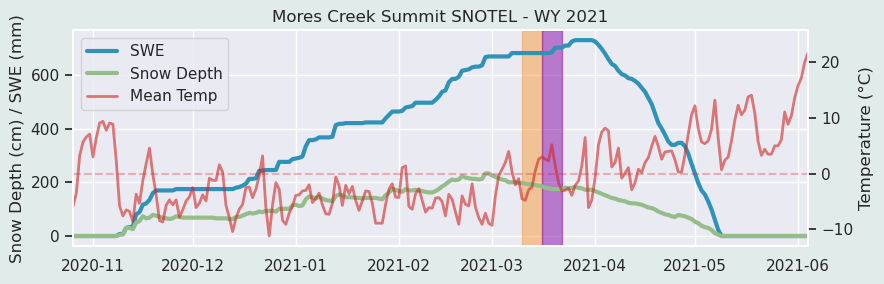

In [22]:
fig, axs = plt.subplots(1, 1, figsize=(9, 3))

data_sets = [
    ("Mores Creek Summit 2021", mores_2021, 0, 1),
]

fig.set_facecolor('#e1ebe9')

for title, df, i, j in data_sets:
    ax = axs
    ax2 = ax.twinx()
    # ax.plot(df['date'], df['precip_in'], label='Precipitation', color='blue')
    lns1 = ax.plot(df['date'], df['swe_mm'], label='SWE', color='#2f92b7', linewidth=3)
    lns2 = ax.plot(df['date'], df['sd_cm'], label='Snow Depth', color='#94bd89', linewidth=3)
    # ax2.plot(df['date'], df['min_temp'], label='Min Temp', color='purple', alpha=0.5)
    # ax2.plot(df['date'], df['max_temp'], label='Max Temp', color='red', alpha=0.5)
    lns3 = ax2.plot(df['date'], df['avg_temp'], label='Mean Temp', color='#D02626', alpha=0.6, linewidth=2)
    # Vertical lines for UAVSAR dates
    start, end = df['date'].min(), df['date'].max()
    start, end = df['date'].iloc[25], df['date'].iloc[-90]
    ax2.hlines(0, start, end, colors='#D02626', linestyles='dashed', alpha=0.3)
    print(start, end)
    ax.set_ylabel('Snow Depth (cm) / SWE (mm)')
    ax2.set_ylabel('Temperature (°C)')
    ax.set_title("Mores Creek Summit SNOTEL - WY 2021")
    for i, d in enumerate(pairs_to_compare):
        d1, d2 = d.split('_')
        dstart, dend = (pd.to_datetime('20' + d2).tz_localize(None) , pd.to_datetime('20' + d1).tz_localize(None)) 
        if start.tz_localize(None) <= dstart <= end.tz_localize(None):
            if i == 0: 
                ax.axvspan(xmin=dstart, xmax=dend, color='#fa9c3d', linestyle=None, alpha=0.5)
            if i == 1: 
                ax.axvspan(xmin=dstart, xmax=dend, color='#8708a6', linestyle=None, alpha=0.5)
    lns = lns1+lns2+lns3
    labs = [l.get_label() for l in lns]
    ax.legend(lns, labs, loc='upper left')
    ax2.grid(False)
    # ax.set_ylim(0, 100)
    ax.set_xlim(start, end)

plt.tight_layout()
plt.show()

R² score for random forest regression: 0.689
RMSE for random forest regression: 0.070
MSE for random forest regression: 0.005


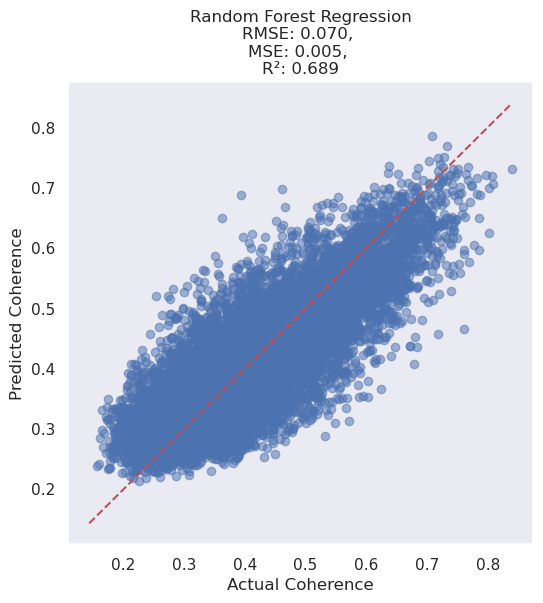

               Feature  Importance
13     incidence_angle    0.163991
27          total_rain    0.154075
23           temp_diff    0.084434
26        total_precip    0.077264
1               aspect    0.072436
11           elevation    0.071386
21          swe_ablate    0.056962
6          canopy_2019    0.051705
18               slope    0.048486
8                curve    0.043317
28          total_snow    0.039585
3             avg_rain    0.039404
9       density_change    0.027505
17           mean_wind    0.018888
22           swe_accum    0.010076
7           cover_2019    0.008220
19          snow_class    0.006559
24       temp_diff_acq    0.004797
10  diurnal_temp_range    0.004259
14            max_temp    0.003806
2           avg_precip    0.002807
15            max_wind    0.002271
4             avg_snow    0.002149
12  freeze_thaw_cycles    0.002051
16           mean_temp    0.001807
25        total_posdeg    0.001761
0       acq_day_precip    0.000000
5            big_acc

In [23]:
# 3. Flatten into ML-ready format
data_array = data_mcs.sel(flight_id=f_id, pair=pairs_to_compare).to_array(dim='variable')  # (variable, pair, flightnum, x, y)
data_2d = data_array.values.reshape(data_array.shape[0], -1).T  # (n_samples, n_features)

# 4. Remove any remaining NaNs for correlation/ML
data_clean = data_2d[~np.isnan(data_2d).any(axis=1)]

# 5. Correlation matrix
corr_matrix = pd.DataFrame(data_clean, 
                           columns=[v for v in data_mcs.data_vars]).corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

c_idx = list(data_mcs.data_vars).index('coherence')
all_other_idxs = [i for i in range(len(data_mcs.data_vars)) if i != c_idx]

# make a random forest model and evaluate
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error, mean_squared_error

# redefine features and target for random forest
X = data_clean[:, all_other_idxs]  # selected variables
y = data_clean[:, c_idx]   # coherence is the target variable

# normalize X features 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into train/test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, 
                                                    test_size=0.2, 
                                                    random_state=42)

# Train random forest regressor
rf_model = RandomForestRegressor(n_estimators=10, 
                                #  max_depth=10,
                                 criterion='squared_error',
                                 random_state=42,
                                 n_jobs=-1,
                                 )
rf_model.fit(X_train, y_train)

# Predict and evaluate
y_pred_rf = rf_model.predict(X_test)
r2_rf = r2_score(y_test, y_pred_rf)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
print(f'R² score for random forest regression: {r2_rf:.3f}')
print(f'RMSE for random forest regression: {rmse_rf:.3f}')
print(f'MSE for random forest regression: {mse_rf:.3f}')

# Plot predicted vs actual coherence for random forest
plt.figure(figsize=(6, 6))
plt.scatter(x=y_test, y=y_pred_rf, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')  # 1:1 line
plt.xlabel('Actual Coherence')
plt.ylabel('Predicted Coherence')
plt.title(f'Random Forest Regression\nRMSE: {rmse_rf:.3f}, \nMSE: {mse_rf:.3f}, \nR²: {r2_rf:.3f}')
plt.grid()
plt.show() 

# Feature importance from random forest
feature_names = [v for v in data_mcs.data_vars if v != 'coherence']
importances_rf = rf_model.feature_importances_
importance_rf_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances_rf})
importance_rf_df = importance_rf_df.sort_values('Importance', ascending=False)
print(importance_rf_df)

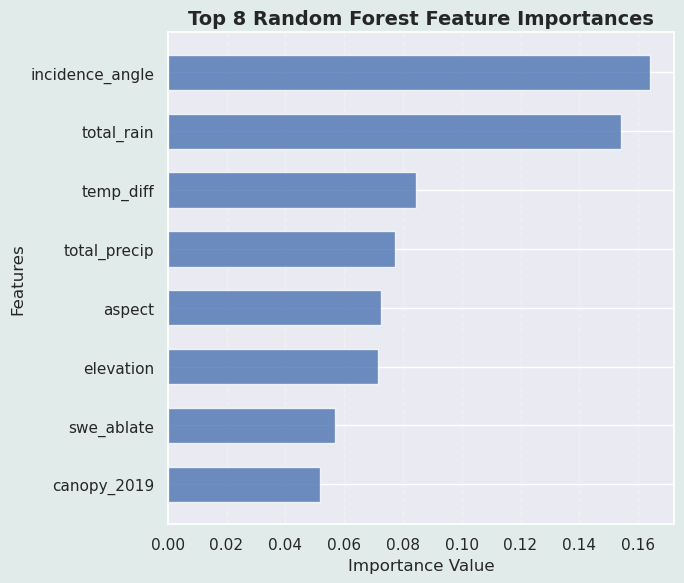

In [24]:
# 1. Create DataFrame
comparison_df = pd.DataFrame({
    'Feature': feature_names,
    'Random Forest': importances_rf
})

# 2. Get the top 8 (sorting descending is usually better for importance)
# Use nlargest if you want the "most important" features at the top
top_features = comparison_df.nlargest(8, 'Random Forest')

# 3. Create horizontal bar plot
fig, ax = plt.subplots(figsize=(7, 6))
fig.set_facecolor('#e1ebe9')

# Use simple integer positions for the Y-axis
y_pos = np.arange(len(top_features))

# Plot bars - removed the "+ width" so they stay centered on the ticks
ax.barh(y_pos, top_features['Random Forest'], height=0.6, 
         alpha=0.8, label='Random Forest')

# 4. Formatting
ax.set_xlabel('Importance Value', fontsize=12)
ax.set_ylabel('Features', fontsize=12)
ax.set_title('Top 8 Random Forest Feature Importances', fontsize=14, fontweight='bold')

# Set ticks to match the number of rows in top_features
ax.set_yticks(y_pos)
ax.set_yticklabels(top_features['Feature'])

# Invert Y-axis so the highest importance is at the top
ax.invert_yaxis() 

ax.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

In [25]:
data = data_mcs

# 1. Separate variables into two lists based on their dimensions
static_vars = [var for var in data.data_vars if (('pair' not in data[var].dims) and ('flight_id' not in data[var].dims))]
pair_vars = [var for var in data.data_vars if (('pair' in data[var].dims) and ('flight_id' not in data[var].dims))]
flight_dynam_vars = [var for var in data.data_vars if (('pair' in data[var].dims) and ('flight_id' in data[var].dims))]
flight_static_vars = [var for var in data.data_vars if (('pair' not in data[var].dims) and ('flight_id' in data[var].dims))]

print(static_vars)
print(pair_vars)
print(flight_static_vars)
print(flight_dynam_vars)

['aspect', 'canopy_2019', 'cover_2019', 'curve', 'elevation', 'slope', 'snow_class']
['acq_day_precip', 'avg_precip', 'avg_rain', 'avg_snow', 'big_accum', 'density_change', 'diurnal_temp_range', 'freeze_thaw_cycles', 'max_temp', 'max_wind', 'mean_temp', 'mean_wind', 'snow_status_change', 'swe_ablate', 'swe_accum', 'temp_diff', 'temp_diff_acq', 'total_posdeg', 'total_precip', 'total_rain', 'total_snow']
['incidence_angle']
['coherence']


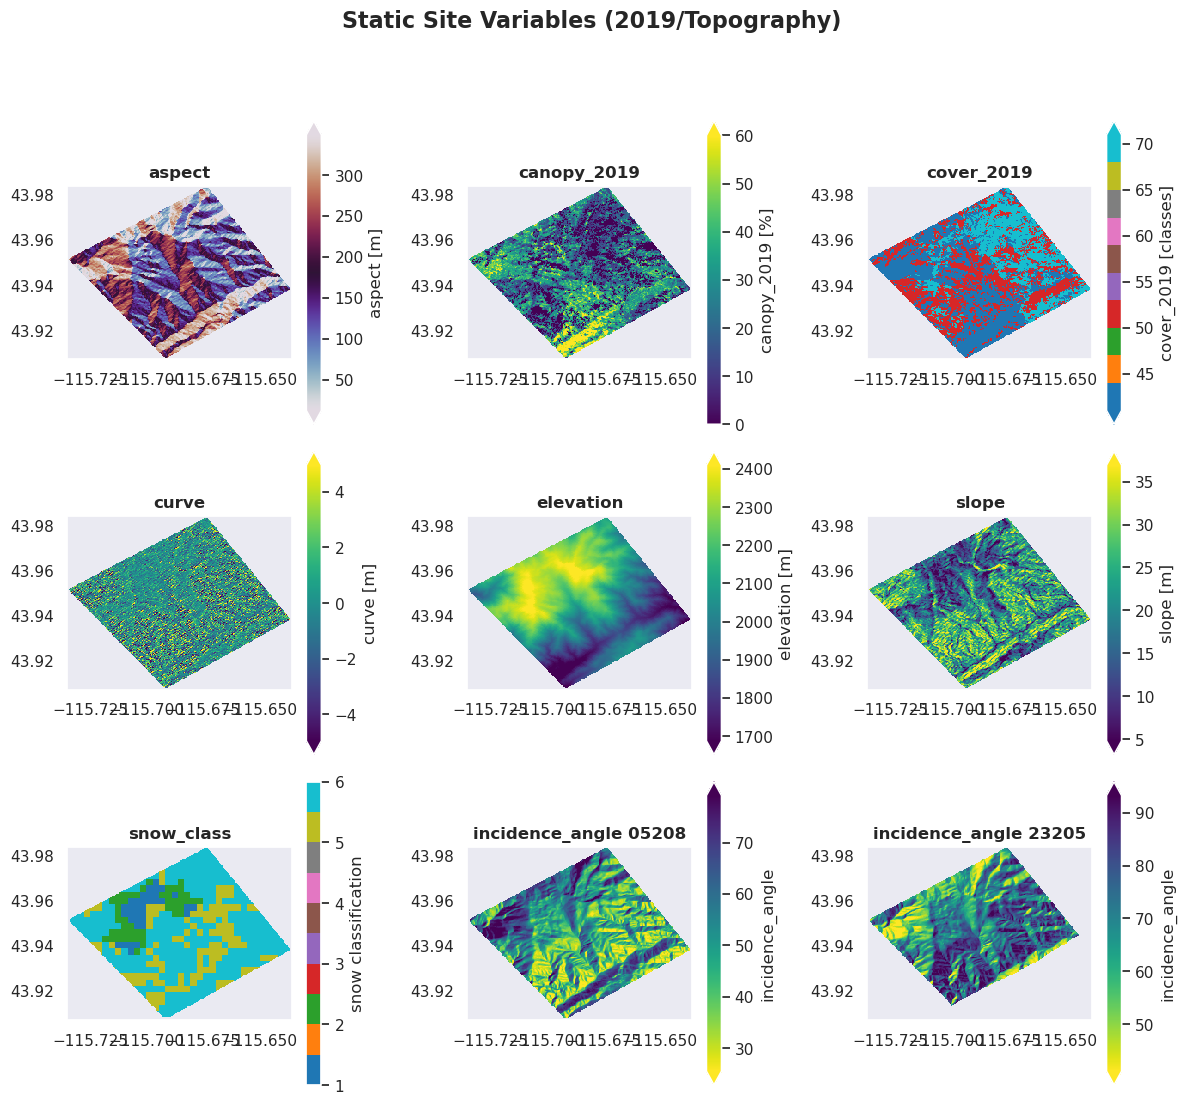

In [26]:

# ==========================================
# 2. PLOT STATIC VARIABLES (Single Dashboard)
# ==========================================
n_static = len(static_vars) + 2 * len(flight_static_vars)
cols = 3
rows = int(np.ceil(n_static / cols))

# Create one figure for all static variables
fig_static, axes_static = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.5))
axes_static = axes_static.flatten()

for i, var in enumerate(static_vars):
    ax = axes_static[i]
    
    if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
    elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
    else: cmap = 'viridis'  # standard colormap for other variables

    # robust=True drops top/bottom 2% of extreme values for a prettier color stretch
    data[var].plot(ax=ax, robust=True, cmap=cmap) 
    
    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_aspect('equal') # Keeps pixels square since this is spatial data

for var in flight_static_vars:
    for i, f in enumerate(['05208', '23205']) : 
        ax = axes_static[i + len(static_vars)]

        if var in 'aspect' : cmap = 'twilight'  # cyclic colormap for aspect
        elif var in ['snow_class', 'cover_2019']: cmap = 'tab10'  # categorical colormap for classes
        if var in 'incidence_angle': cmap = 'viridis_r'
        else: cmap = 'viridis'  # standard colormap for other variables
        # print(i + len(static_vars))
        # print(f)
        data[var].sel(flight_id=f).plot(ax=ax, robust=True, cmap=cmap) 
        # .plot(ax=ax, robust=True, cmap=cmap) 
    
        ax.set_title(var + ' ' + f, fontweight='bold')
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_aspect('equal') # Keeps pixels square since this is spatial data

# Hide any empty subplots if n_static doesn't divide perfectly by 3
# for j in range(i + 1, len(axes_static)):
#     axes_static[j].set_visible(False)

fig_static.suptitle('Static Site Variables (2019/Topography)', fontsize=16, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()



In [27]:
# 3. Flatten into ML-ready format
data_array = data_mcs.to_array(dim='variable')  # (variable, pair, flightnum, x, y)
data_2d = data_array.values.reshape(data_array.shape[0], -1).T  # (n_samples, n_features)

# 4. Remove any remaining NaNs for correlation/ML
data_clean = data_2d[~np.isnan(data_2d).any(axis=1)]

# 5. Correlation matrix
corr_matrix = pd.DataFrame(data_clean, 
                           columns=[v for v in data.data_vars]).corr()
corr_matrix.style.background_gradient(cmap='coolwarm')

/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pandas/io/formats/style.py:4202: RuntimeWarning: All-NaN slice encountered
  smin = np.nanmin(gmap) if vmin is None else vmin
/bsuhome/julialober/miniforge3/envs/coherence_v2/lib/python3.11/site-packages/pandas/io/formats/style.py:4203: RuntimeWarning: All-NaN slice encountered
  smax = np.nanmax(gmap) if vmax is None else vmax


,acq_day_precip,aspect,avg_precip,avg_rain,avg_snow,big_accum,canopy_2019,coherence,cover_2019,curve,density_change,diurnal_temp_range,elevation,freeze_thaw_cycles,incidence_angle,max_temp,max_wind,mean_temp,mean_wind,slope,snow_class,snow_status_change,swe_ablate,swe_accum,temp_diff,temp_diff_acq,total_posdeg,total_precip,total_rain,total_snow
acq_day_precip,1.000000,0.006080,0.233816,-0.158652,0.257086,nan,0.000578,-0.059692,-0.002028,0.000190,-0.038255,-0.239668,0.029469,-0.112345,-0.031255,-0.186223,0.224569,-0.242860,0.197079,-0.011029,-0.016963,nan,-0.133048,0.251293,-0.113623,-0.089118,-0.246089,0.105232,-0.125693,0.114860
aspect,0.006080,1.000000,0.010192,-0.013175,0.012600,nan,0.199654,0.021180,-0.226766,0.012467,0.014535,-0.062147,0.024276,-0.024668,-0.120075,-0.039806,0.071331,-0.037199,0.086663,0.054098,-0.032368,nan,0.046913,0.071532,-0.012048,-0.000184,-0.017753,0.001536,-0.026000,0.003497
avg_precip,0.233816,0.010192,1.000000,-0.120628,0.975245,nan,-0.003650,-0.267043,-0.007645,0.000245,-0.149023,-0.350925,0.081298,-0.056307,0.018287,-0.201741,0.443336,-0.548744,0.365897,-0.021498,-0.039527,nan,-0.266696,0.840919,0.262088,-0.000406,-0.507987,0.628384,-0.127844,0.638981
avg_rain,-0.158652,-0.013175,-0.120628,1.000000,-0.337154,nan,0.023297,-0.065644,0.002899,-0.001081,-0.006177,0.214641,-0.204778,0.182604,-0.070134,0.332247,-0.297870,0.607925,-0.275624,0.058801,0.103838,nan,0.521142,-0.361115,-0.287616,0.001463,0.680547,-0.246168,0.687911,-0.298353
avg_snow,0.257086,0.012600,0.975245,-0.337154,1.000000,nan,-0.008652,-0.238634,-0.007896,0.000473,-0.139954,-0.380621,0.122716,-0.094076,0.032966,-0.265336,0.486800,-0.655833,0.408404,-0.033486,-0.060617,nan,-0.369014,0.877946,0.312625,-0.000710,-0.633357,0.650778,-0.274479,0.672453
big_accum,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan,nan
canopy_2019,0.000578,0.199654,-0.003650,0.023297,-0.008652,nan,1.000000,-0.073376,-0.537380,0.037889,0.004269,-0.034790,-0.174069,0.011534,-0.081603,-0.000519,-0.051937,0.050592,-0.054387,0.053685,0.092643,nan,0.026164,0.015845,-0.017268,-0.028598,0.031266,-0.010160,0.026871,-0.012200
coherence,-0.059692,0.021180,-0.267043,-0.065644,-0.238634,nan,-0.073376,1.000000,0.128175,0.033013,-0.248192,-0.003560,0.063776,-0.265534,-0.011744,-0.185179,-0.182257,0.045132,-0.026543,-0.007600,0.020318,nan,-0.032911,-0.210007,-0.099239,0.036698,0.038539,-0.334643,-0.173964,-0.322059
cover_2019,-0.002028,-0.226766,-0.007645,0.002899,-0.007896,nan,-0.537380,0.128175,1.000000,-0.005970,-0.035463,0.100978,0.097801,-0.002364,0.043750,0.029790,-0.035379,-0.012344,-0.045979,-0.015035,-0.018630,nan,-0.085129,-0.016913,0.019485,0.021291,0.010798,-0.002281,0.008383,-0.002916
curve,0.000190,0.012467,0.000245,-0.001081,0.000473,nan,0.037889,0.033013,-0.005970,1.000000,-0.000537,0.000562,0.057794,-0.000605,-0.017128,0.000192,0.001896,-0.001566,0.002466,0.007043,-0.005706,nan,-0.003967,0.003643,0.000244,0.000730,-0.001061,0.000216,-0.001617,0.000338


In [28]:

# # ==========================================
# # 3. PLOT DYNAMIC VARIABLES (One Figure Each)
# # ==========================================
# for var in pair_vars:
#     # Pick a diverging colormap for 'change' variables, standard for others
#     cmap = 'RdBu' if 'change' in var else 'viridis'
    
#     # Xarray automatically creates a multi-panel figure when you use col=
#     # plot only nearest_dates
#     fg = data[var].sel(pair=dates).plot(
#         col='pair',
#         col_wrap=5,  # 5 plots per row looks nice for 45 pairs
#         figsize=(15, 3 * int(np.ceil(len(dates) / 5))),
#         robust=True,
#         cmap=cmap
#     )

#     # fg = data[var].plot(
#     #     col='pair',
#     #     col_wrap=5,  # 5 plots per row looks nice for 45 pairs
#     #     figsize=(15, 3 * int(np.ceil(data.sizes['pair'] / 5))),
#     #     robust=True,
#     #     cmap=cmap
#     # )
    
#     # Add a main title for this specific variable's figure
#     fg.fig.suptitle(f'Dynamic Variable: {var}', fontsize=16, fontweight='bold', y=1.02)
    
#     # Clean up the individual axes
#     for ax in fg.axs.flat:
#         ax.set_xlabel('')
#         ax.set_ylabel('')
#         ax.set_aspect('equal')
        
#     plt.show()